In [1]:
# This cells setups the environment when executed in Google Colab.
try:
    import google.colab
    !curl -s https://raw.githubusercontent.com/ibs-lab/cedalion/dev/scripts/colab_setup.py -o colab_setup.py
    # Select branch with --branch "branch name" (default is "dev")
    %run colab_setup.py
except ImportError:
    pass

In [2]:
import cedalion
import cedalion.sigproc.quality as quality
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
import xarray as xr
from cedalion import units
from cedalion.sigdecomp.multimodal import arc_ebm, arsc_erbm
import cedalion.data

# Spectrally Constrained Independent Component Analysis (ICA)

In this notebook, we demonstrate how constrained ICA methods can be applied to separate physiological sources from resting-state fNIRS data using auxiliary measurements. Specifically, we focus on adaptive-reverse spectrally constrained ICA-ERBM (arsc-ERBM) and adaptive-reverse spectrally constrained ICA-EBM (arsc-EBM).

arsc-ERBM and arsc-EBM are constrained versions of the methods [Independent Component Analysis by Entropy Rate Bound Minimization](https://ieeexplore.ieee.org/stamp/stamp.jsp?tp=&arnumber=6845364) (ICA-ERBM) and [by Entropy Bound Minimization](https://ieeexplore.ieee.org/abstract/document/5499122) (ICA-EBM). The general assumption in [Independent Component Analysis](https://en.wikipedia.org/wiki/Independent_component_analysis) is that the dataset $X \in \mathbb R^{N\times T}$, with $N$ channels and $T$ sample points, is generated from a set of independent latent sources $S \in \mathbb R^{N\times T}$, mixed by an unknown mixing matrix $A \in \mathbb R^{N \times N}$.

$$
X = A \cdot S.
$$

ICA methods aim to undo this mixing by determining a demixing matrix $W \in \mathbb{R}^{N \times N}$, such that the estimated underlying sources $Y = W \cdot X$ are maximally independent. The optimization of the demixing matrix is based on minimizing the mutual information $I$ in the case of ICA-EBM, and the mutual information rate $I_r$ in the case of ICA-ERBM. In both methods, this is done by minimizing a cost function $J$ that is equivalent to either $I$ or $I_r$ for each row vector $w_n$, $n = 1, ..., N$.

In the constrained methods arsc-EBM and arsc-ERBM, we assume that there are $M \leq N$ reference signals $r_n$, $n = 1, ..., M$, that correspond to $M$ latent sources. For each source estimate $y_n = w_n^T X$ that corresponds to a reference signal, the minimization of the cost function $J$ is extended through a constraint that uses a reference signal $r_n$:

$$
\min_{w_n} J(w_n) \quad \text{s.t.} \quad \varepsilon(r_n, y_n) \geq \rho_n
$$

Here, $\varepsilon$ is a similarity measure that operates in the frequency domain and enforces similar spectral characteristics between the source estimate $y_n$ and the reference signal $r_n$.

In the following example, $X$ represents our resting-state fNIRS data, and as reference signals $r_n$, we use auxiliary PPG, respiration, and mean arterial pressure (MAP) measurements. After applying the constrained ICA methods and obtaining $W$, we can compute estimates of the separated sources as $y_n = w_n^T X$.



## Loading Resting-State fNIRS Data

We load the resting-state fNIRS data, including the auxiliary physiological measurements from the SNIRF file. For the demixing problem, we use middle-distance channels of approximately 15 mm in length to ensure that physiological noise signals are present in the data.

In [3]:
# Load data
rec = cedalion.data.get_spa_fnirs()
    
# Read fnirs data 
fnirs_amp = rec['amp']


# Define middle distance channels 
middle_channels = ['S1D7', 'S1D8', 'S1D13', 'S1D14', 'S1D15', 'S1D16', 'S2D8', 'S2D11', 'S2D12', 
                   'S3D7', 'S3D9', 'S3D10', 'S4D1', 'S4D5', 'S4D10', 'S4D16', 'S5D4', 'S5D5', 'S5D11', 
                   'S5D15', 'S6D3', 'S6D6', 'S6D12', 'S6D14', 'S7D2', 'S7D6', 'S7D9', 'S7D13', 'S8D22', 
                   'S8D23', 'S8D24', 'S8D29', 'S8D30', 'S8D31', 'S9D24', 'S9D27', 'S9D28', 'S10D23', 'S10D25',
                   'S10D26', 'S11D19', 'S11D26', 'S11D31', 'S12D18', 'S12D19', 'S12D22', 'S12D28', 'S13D17', 
                   'S13D20', 'S13D27', 'S13D29', 'S14D20', 'S14D21', 'S14D25', 'S14D30']


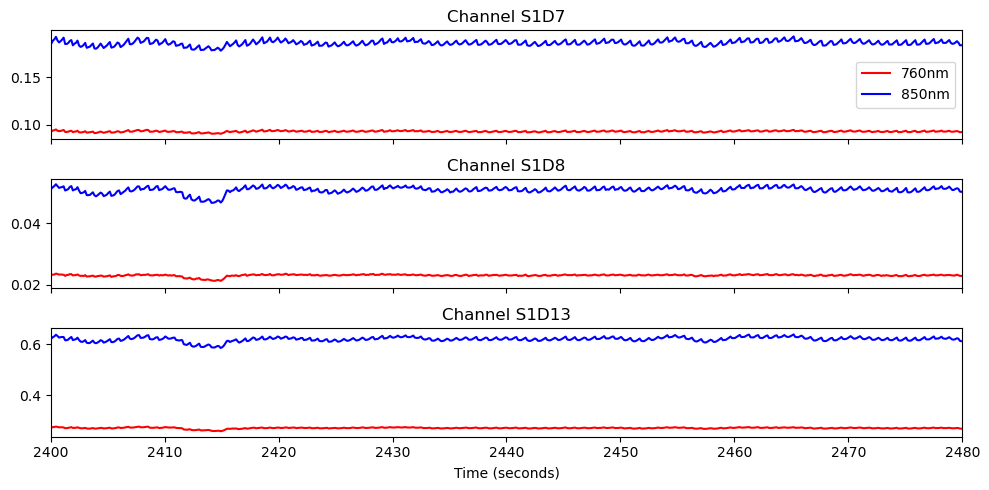

In [4]:
# Plot three middle distance channels
fig, ax = plt.subplots(3, 1, sharex=True, figsize=(10, 5))
for i, ch in enumerate(['S1D7', 'S1D8', 'S1D13']):
    ax[i].plot(fnirs_amp.time, fnirs_amp.sel(channel=ch, wavelength="760"), "r-", label="760nm")
    ax[i].plot(fnirs_amp.time, fnirs_amp.sel(channel=ch, wavelength="850"), "b-", label="850nm")
    ax[i].set_title(f"Channel {ch}")

ax[0].legend()
ax[2].set_xlim(2400,2480)
ax[2].set_xlabel("Time (seconds)")
plt.tight_layout()

## Conversion to Optical Density

In [5]:
# Convert to OD
fnirs_od = cedalion.nirs.cw.int2od(fnirs_amp)

## Select Resting-State Session

Our data contain a resting-state session of 75 seconds. We select this session and crop the first 10 seconds to remove non-stationarities in the data. From the remaining session, we select a 60-second interval for our analysis using the middle-distance channels.

In [6]:
# Select the onset of the resting state interval (pre_sitting) 
onset_resting = rec.stim[rec.stim.trial_type == 'pre_sitting'].onset.values[0]

# We cropp the first 10 seconds of the resting state interval to 
# avoid transient effects and select a 60 second interval for the analysis.
interval = [onset_resting + 10, onset_resting + 70]

# Select interval and channels 
interval_fnirs_od = fnirs_od.sel(time=slice(interval[0], interval[1]))
interval_fnirs_od = interval_fnirs_od.sel(channel= middle_channels)

## Channel Quality Assessment and Pruning

We compute the Scalp Coupling Index (SCI) and Peak Spectral Power (PSP) for channel quality assessment. SCI and PSP are computed for each channel, and we then select the 40 channels with the highest percentage of clean time.

In [7]:
# Define parameters for quality metrics
window_length = 5 * units.s
sci_thresh = 0.75
psp_thresh = 0.1
sci_psp_percentage_thresh = 0.75

# Compute SCI and PSP 
sci, sci_mask = quality.sci(interval_fnirs_od, window_length, sci_thresh)
psp, psp_mask = quality.psp(interval_fnirs_od, window_length, psp_thresh)
sci_x_psp_mask = sci_mask & psp_mask
perc_time_clean = sci_x_psp_mask.sum(dim="time") / len(sci.time)

# Set the number of channels to include in the ICA analysis
num_ch = 40

# Select the best channels 
id_best_channels = np.argsort(perc_time_clean)[-num_ch:]
best_channels = id_best_channels['channel']
best_middle_channels = interval_fnirs_od.sel(channel=best_channels)

## Convert Optical Density to Concentration Changes 

In [8]:
#  Convert optical density to concentration changes 
montage = rec.geo3d
dpf = xr.DataArray(
    [6, 6],
    dims="wavelength",
    coords={"wavelength": fnirs_od.wavelength},)
    
fnirs_con = cedalion.nirs.cw.od2conc(fnirs_od, montage, dpf)

## High-Pass Filtering and Selection of HbO

In [9]:
# Apply high-pass filter
y_filt = fnirs_con.cd.freq_filter(fmin= 0.01, fmax= 0, butter_order=4)

# Select resting state interval
y_filt = y_filt.sel(time = slice(interval[0], interval[1]))

# Select middle distance channels
y_filt = y_filt.sel(channel=best_middle_channels.channel.values)

# Select only HbO signal 
y_filt = y_filt.sel(chromo = 'HbO')

# Turn to numpy array 
data = y_filt.values

/opt/miniconda3/envs/cedalion/lib/python3.11/site-packages/xarray/core/variable.py:315: UnitStrippedWarning: The unit of the quantity is stripped when downcasting to ndarray.
  data = np.asarray(data)


## Prepare the Auxiliary Signals

We now extract the respiration ('Resp'), PPG ('Pleth'), or mean arterial pressure ('MAP') signals from the recording. These signals must be downsampled to match the fNIRS sampling frequency. We first select the resting-state interval with an additional buffer and apply a band-pass filter to the data to avoid aliasing effects. The MAP signal may contain missing samples, which we address using an interpolation step.

In [10]:
# Select the auxiliary signal from the recording 
aux_name = 'Resp' # use 'MAP', 'Pleth' or 'Resp' 
aux_signal = rec.aux_ts[aux_name]

# Select the interval of the auxiliary signal with a 100 second buffer 
# before and after the resting state interval to avoid edge effects in the filtering step
buffer = 100 
aux_signal = aux_signal.sel(time = slice(interval[0]- buffer, interval[1] + buffer ))

# Add a new coordinate called samples and add unit 
aux_signal['time'].attrs['units'] = 'seconds'
samples = np.arange(aux_signal.sizes['time'])
aux_signal = aux_signal.assign_coords(samples=('time', samples))

# Fix missing samples in the MAP signal 
if aux_name == 'MAP':
    aux_signal = aux_signal.interpolate_na(dim = 'time' ,method = 'cubic',
                                               fill_value='extrapolate')

# Apply bandpass filter to the auxiliary signal to avaoid aliasing effects after the downsampling step.
aux_signal = aux_signal.cd.freq_filter(fmin= 0.01, fmax= 2.5 , butter_order=4) 

# Downsample the auxiliary signal by interpolating it to the time points of the fNIRS signal
time_line = fnirs_con.sel(time = slice(interval[0]- buffer,interval[1]+buffer))
aux_signal = aux_signal.drop_duplicates(dim='time')
aux_signal = aux_signal.interp(time=time_line.time)
aux_signal = aux_signal.dropna(dim="time", how="any")

# Remove buffer 
aux_signal = aux_signal.sel(time = slice(interval[0], interval[1]))

# Turn to numpy array and reshape 
aux_signal = np.array(aux_signal.values, dtype=np.float64).T
aux_signal = aux_signal.reshape(1, -1)  


## Z-Transform Normalization

In [11]:
# z-transform the data and auxiliary signal
data = sp.stats.zscore(data, axis=1) 
aux_signal = sp.stats.zscore(aux_signal, axis=1) 

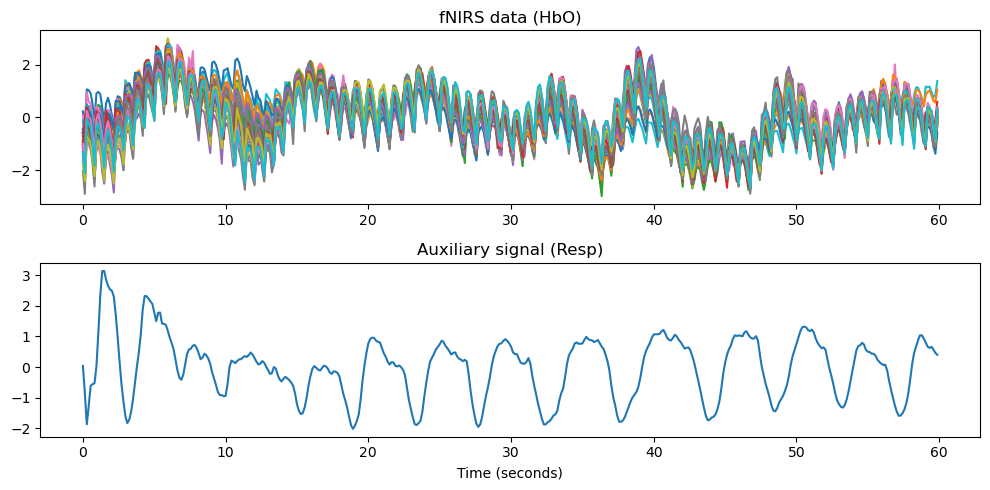

In [12]:
# Plot the data and the auxiliary signal
fig, ax = plt.subplots(2, 1, figsize=(10, 5))

x_time = np.arange(data.shape[1]) * 1/(7.4)
ax[0].plot(x_time, data.T)
ax[0].set_title('fNIRS data (HbO)')
ax[1].plot(x_time, aux_signal[0])
ax[1].set_title(f'Auxiliary signal ({aux_name})')
ax[1].set_xlabel('Time (seconds)')

plt.tight_layout()
plt.show()


## Apply Constrained ICA Methods

We define a frequency reference signal by computing the power spectral density of the reference signal. We then apply the constrained ICA methods to the data.

In [13]:
# Create the time domain and frequency domain reference signals 
ref = np.copy(aux_signal)
ref_psd = (2/ ref.shape[1] ) * np.abs(np.fft.rfft(ref, axis = 1 )**2)

In [14]:
# Set the filter length for arsc-ERBM
p = 11

# Apply ICA methods 
W1 = arsc_erbm.arsc_erbm(data, ref_psd.T, p)
W2 = arsc_erbm.arsc_erbm(data, ref_psd.T, p, ref.T)

# We call arsc-EBM through the arc-EBM function, specifying the constraint type as  "psd"
W3 = arc_ebm.arc_ebm(data, ref_psd.T, 'psd')

## Compute Source Estimates

For each constrained method, the first row of the demixing matrix corresponds to the referenced source. We therefore select the first row and compute the source estimate as $y = w_0^T X$.

In [15]:
# Compute the estimated sources
source_arsc_erbm = W1[0].dot(data)
source_arsc_erbm_pr = W2[0].dot(data)
source_arsc_ebm = W3[0].dot(data)

# z-transform the estimated sources
source_arsc_erbm = sp.stats.zscore(source_arsc_erbm)
source_arsc_erbm_pr = sp.stats.zscore(source_arsc_erbm_pr)
source_arsc_ebm = sp.stats.zscore(source_arsc_ebm)

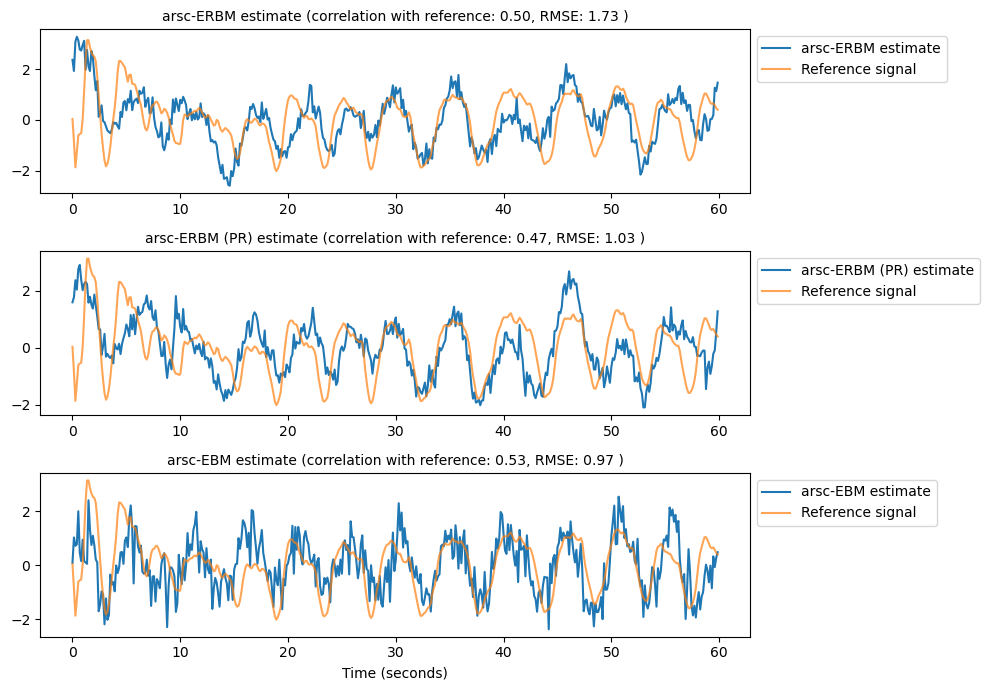

In [16]:
# Plot source estimates and reference signal
fig, ax = plt.subplots(3, 1, figsize=(10, 7))

estimates = [source_arsc_erbm, source_arsc_erbm_pr, source_arsc_ebm]
labels = ['arsc-ERBM estimate', 'arsc-ERBM (PR) estimate', 'arsc-EBM estimate']
for i in range(3):
    # Compute peak cross correlation for +/- 2 seconds lag 
    lags = np.arange(-15, 16, 1)
    cross_corr = [np.corrcoef(ref, np.roll(estimates[i], lag, axis=0))[0, 1] for lag in lags]
    max_corr = np.max(np.abs(cross_corr))
    best_lag = lags[np.argmax(np.abs(cross_corr))]

    # Copmute RMSE between reference and estimate 
    rmse = np.sqrt(np.mean((ref - np.roll(estimates[i], best_lag, axis=0))**2)) 
    ax[i].set_title(f'{labels[i]} (correlation with reference: {max_corr:.2f}, RMSE: {rmse:.2f} )', 
    fontsize=10)

    # Plot estimate and reference 
    signal = np.roll(estimates[i], best_lag, axis=0)
    signal = np.sign(np.corrcoef(ref, signal)[0, 1]) * signal
    ax[i].plot(x_time, signal, label = labels[i])
    ax[i].plot(x_time, ref.T, label = 'Reference signal', alpha = 0.7)
    ax[i].legend( loc='upper left', bbox_to_anchor=(1, 1))


ax[2].set_xlabel('Time (seconds)')
plt.tight_layout()
plt.show()

## References

In [17]:
cedalion.bib.dump_to_notebook()

[1],Tucker2022,cedalion.io.snirf.read_snirf,"Stephen Tucker, Jay Dubb, Sreekanth Kura, Alexander von Lühmann, Robert Franke, Jörn M. Horschig, Samuel Powell, Robert Oostenveld, Michael Lührs, Édouard Delaire, Zahra M. Aghajan, Hanseok Yun, Meryem A. Yücel, Qianqian Fang, Theodore J. Huppert, Blaise deB. Frederick, Luca Pollonini, David A. Boas, and Robert Luke. Introduction to the shared near infrared spectroscopy format. Neurophotonics, 10(1):013507, 2022. doi:10.1117/1.NPh.10.1.013507."
[2],Delpy1988,"cedalion.nirs.cw.int2od, cedalion.nirs.cw.od2conc","D. T. Delpy, M. Cope, P. van der Zee, S. Arridge, S. Wray, and J. Wyatt. Estimation of optical pathlength through tissue from direct time of flight measurement. Physics in Medicine and Biology, 33(12):1433–1442, 1988. doi:10.1088/0031-9155/33/12/008."
[3],Villringer1997,"cedalion.nirs.cw.int2od, cedalion.nirs.cw.od2conc","Arno Villringer and Britton Chance. Non-invasive optical spectroscopy and imaging of human brain function. Trends in Neurosciences, 20(10):435–442, 1997. doi:10.1016/S0166-2236(97)01132-6."
[4],Pollonini2014,"cedalion.sigproc.quality.psp, cedalion.sigproc.quality.sci","Luca Pollonini, Cristen Olds, Homer Abaya, Heather Bortfeld, Michael S. Beauchamp, and John S. Oghalai. Auditory cortex activation to natural speech and simulated cochlear implant speech measured with functional near-infrared spectroscopy. Hearing Research, 309:84–93, 2014. doi:https://doi.org/10.1016/j.heares.2013.11.007."
[5],Pollonini2016,"cedalion.sigproc.quality.psp, cedalion.sigproc.quality.sci","Luca Pollonini, Heather Bortfeld, and John S. Oghalai. PHOEBE: a method for real time mapping of optodes-scalp coupling in functional near-infrared spectroscopy. Biomedical Optics Express, 7(12):5104, Dec 2016. doi:10.1364/BOE.7.005104."
[6],Prahl1998,cedalion.nirs.common.get_extinction_coefficients,"Scott A. Prahl. Optical absorption of hemoglobin. Oregon Medical Laser Center, online resource, 1998. URL: https://omlc.org/spectra/hemoglobin/."
[7],Li2010B,cedalion.sigdecomp.multimodal.arsc_erbm.arsc_erbm,"Xi-Lin Li and Tulay Adali. Blind spatiotemporal separation of second and/or higher-order correlated sources by entropy rate minimization. In 2010 IEEE International Conference on Acoustics, Speech and Signal Processing, 1934–1937. Dallas, TX, March 2010. IEEE. doi:10.1109/ICASSP.2010.5495311."
[8],Li2010A,cedalion.sigdecomp.multimodal.arc_ebm.arc_ebm,"Xi-Lin Li and Tülay Adali. Independent Component Analysis by Entropy Bound Minimization. IEEE Transactions on Signal Processing, 58(10):5151–5164, Oct 2010. doi:10.1109/TSP.2010.2055859."
[9],yang2025flexible,cedalion.sigdecomp.multimodal.arc_ebm.arc_ebm,"Hanlu Yang, Trung Vu, Ehsan Ahmed Dhrubo, Vince D Calhoun, and Tülay Adali. A flexible constrained ica approach for multisubject fmri analysis. International Journal of Biomedical Imaging, 2025(1):2064944, 2025. doi:10.1155/ijbi/2064944."
